### **Entrega 3 — Chunking de Manifestações Longas (2,0 pts)**

As 5 manifestações mais longas devem ser divididas em chunks usando a estratégia RecursiveCharacterTextSplitter do LangChain. Teste pelo menos duas configurações diferentes de (chunk_size, chunk_overlap) e responda:

- Como o overlap influencia a coesão semântica entre chunks consecutivos?
- Qual configuração preserva melhor o sentido das denúncias? Justifique com exemplos.
- Visualize os chunks no espaço 2D (PCA ou t-SNE). Os chunks de uma mesma manifestação ficam próximos?

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter


## 1. Seleção das 5 manifestações mais longas

In [2]:
with open("../data/manifestacoes.json", encoding="utf-8") as f:
    df = pd.DataFrame(json.load(f))

df["tamanho"] = df["texto"].str.len()
longas = df.nlargest(5, "tamanho")[["id", "categoria_oficial", "tamanho", "texto"]].reset_index(drop=True)
longas[["id", "categoria_oficial", "tamanho"]]


,id,categoria_oficial,tamanho
0,M037,meio ambiente,669
1,M012,infraestrutura,650
2,M018,saúde,646
3,M027,infraestrutura,640
4,M036,educação,624


## 2. Chunking com diferentes configurações

Configurações testadas:
- **A** — `chunk_size=300`, `chunk_overlap=0` (sem overlap)
- **B** — `chunk_size=300`, `chunk_overlap=60` (mesmo tamanho, com overlap: isola o efeito do overlap)
- **C** — `chunk_size=150`, `chunk_overlap=30` (chunks menores)

In [3]:
configs = {
    "A (300/0)": (300, 0),
    "B (300/60)": (300, 60),
    "C (150/30)": (150, 30),
}

def dividir(texto, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],  # prefere quebrar em fim de frase
    )
    return splitter.split_text(texto)

# chunks[config] = lista de (id_manifestacao, texto_do_chunk)
chunks = {}
for nome, (size, overlap) in configs.items():
    chunks[nome] = []
    for _, linha in longas.iterrows():
        for c in dividir(linha["texto"], size, overlap):
            chunks[nome].append((linha["id"], c))

for nome in configs:
    print(f"Config {nome}: {len(chunks[nome])} chunks no total")


Config A (300/0): 15 chunks no total
Config B (300/60): 15 chunks no total
Config C (150/30): 31 chunks no total


In [4]:
# Exemplo: chunks da mesma manifestação em cada configuração
id_exemplo = longas.loc[0, "id"]

for nome in configs:
    print(f"===== Config {nome} - {id_exemplo} =====")
    for i, (mid, c) in enumerate(chunks[nome]):
        if mid == id_exemplo:
            print(f"[chunk {i}] ({len(c)} chars) {c}\n")


===== Config A (300/0) - M037 =====
[chunk 0] (205 chars) Solicito fiscalização de uma oficina que está descartando óleo e outros resíduos de forma inadequada. O material pode contaminar o solo e chegar à rede de drenagem, principalmente durante períodos de chuva

[chunk 1] (210 chars) . Moradores próximos relatam manchas no chão e presença de resíduos líquidos nas proximidades do estabelecimento. A preocupação aumenta porque existe uma galeria de águas pluviais relativamente próxima ao local

[chunk 2] (254 chars) . A comunidade solicita uma vistoria dos órgãos responsáveis, orientação sobre o armazenamento e descarte correto dos resíduos e, caso sejam confirmadas irregularidades, a adoção das medidas administrativas cabíveis para evitar novos impactos ambientais.

===== Config B (300/60) - M037 =====
[chunk 0] (205 chars) Solicito fiscalização de uma oficina que está descartando óleo e outros resíduos de forma inadequada. O material pode contaminar o solo e chegar à rede de drenagem,

## 3. Embeddings dos chunks

In [5]:
model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = {}
for nome in configs:
    textos_chunks = [c for _, c in chunks[nome]]
    embeddings[nome] = model.encode(textos_chunks, normalize_embeddings=True)
    print(nome, embeddings[nome].shape)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

A (300/0) (15, 384)
B (300/60) (15, 384)
C (150/30) (31, 384)


## 4. Influência do overlap na coesão entre chunks consecutivos

In [6]:
# Similaridade média entre chunks consecutivos da mesma manifestação
linhas = []
for nome in configs:
    ids_chunks = [mid for mid, _ in chunks[nome]]
    sim = cosine_similarity(embeddings[nome])

    sims_consecutivos = [
        sim[i, i + 1]
        for i in range(len(ids_chunks) - 1)
        if ids_chunks[i] == ids_chunks[i + 1]
    ]
    linhas.append({
        "config": nome,
        "chunks": len(ids_chunks),
        "sim. média entre chunks consecutivos": round(sum(sims_consecutivos) / len(sims_consecutivos), 4),
    })

pd.DataFrame(linhas)


,config,chunks,sim. média entre chunks consecutivos
0,A (300/0),15,0.5613
1,B (300/60),15,0.5613
2,C (150/30),31,0.4237


## 5. Visualização 2D (PCA)

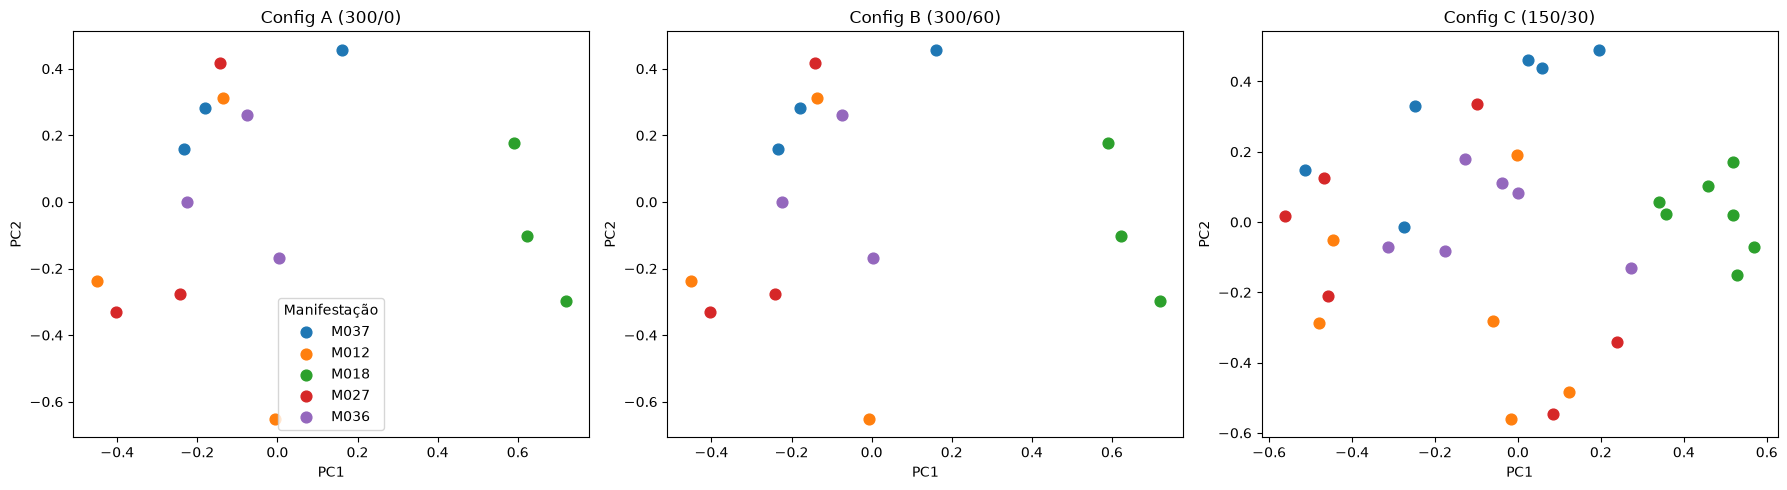

In [7]:
fig, axes = plt.subplots(1, len(configs), figsize=(18, 5))

for ax, nome in zip(axes, configs):
    pontos = PCA(n_components=2).fit_transform(embeddings[nome])
    ids_chunks = [mid for mid, _ in chunks[nome]]

    for mid in longas["id"]:
        idx = [i for i, m in enumerate(ids_chunks) if m == mid]
        ax.scatter(pontos[idx, 0], pontos[idx, 1], label=mid, s=60)

    ax.set_title(f"Config {nome}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

axes[0].legend(title="Manifestação")
plt.tight_layout()
plt.show()


## 6. Discussão

**Como o overlap influencia a coesão semântica entre chunks consecutivos?**
As configurações A (overlap 0) e B (overlap 60) produziram resultados idênticos: 15 chunks, os mesmos cortes e a mesma similaridade média entre chunks consecutivos (0.5613). Isso acontece porque, com o separador ". ", o splitter monta os chunks juntando frases inteiras, e o overlap só consegue reaproveitar pedaços já separados. Como cada frase tem cerca de 100 caracteres ou mais, nenhuma cabe em um overlap de 60 e ele não é aplicado. O overlap só apareceu na configuração C, no ponto em que o splitter precisou quebrar dentro de uma frase: o chunk 4 termina em "caso sejam" e o chunk 5 recomeça em "dos resíduos e, caso sejam", repetindo palavras que ligam os dois trechos. Portanto, o overlap funciona como ponte quando o corte cai no meio de uma ideia e é irrelevante quando os cortes já coincidem com fronteiras de frase. A menor similaridade média da C (0.42, contra 0.56 em A e B) se explica pelo tamanho menor dos chunks, e não pelo overlap: cada chunk cobre um trecho mais estreito do texto e, por isso, se parece menos com o vizinho.

**Qual configuração preserva melhor o sentido das denúncias?**
As configurações A e B. Em M037, os três chunks correspondem a três unidades de sentido: (1) o problema, uma oficina descartando óleo e resíduos com risco de contaminação; (2) as evidências, com manchas no chão e a galeria de águas pluviais próxima; e (3) a solicitação, com vistoria, orientação e medidas administrativas. Cada chunk, isolado, ainda responde a "o que está sendo denunciado" ou "o que se pede". Na configuração C, cada frase vira um chunk e o contexto se perde: "O material pode contaminar o solo..." fica sem o referente (qual material? a oficina só aparece no chunk anterior), e a solicitação final é cortada no meio, separando "caso sejam" de "confirmadas irregularidades, a adoção das medidas administrativas...". Em compensação, os chunks menores da C são mais específicos e podem favorecer buscas por detalhes pontuais (como "galeria de águas pluviais"). Para triagem de manifestações, em que o sentido completo da denúncia importa mais, a escolha é a configuração A (ou B, equivalente aqui). Os exemplos vêm de M037 e valem como amostra, não como prova para as cinco manifestações.

**Os chunks de uma mesma manifestação ficam próximos no espaço 2D?**
Apenas em parte. Nas configurações A e B (gráficos idênticos), a única manifestação que forma um grupo compacto é M018, isolada à direita (PC1 entre 0.6 e 0.7), coerente com o tema distinto (demora em exames de saúde). As outras quatro (M012, M027, M036 e M037) se misturam na região esquerda, e chunks de manifestações diferentes ficam tão próximos quanto chunks da mesma manifestação (por exemplo, pontos de M037, M012, M027 e M036 quase sobrepostos perto de PC1 = -0.2 e PC2 = 0.3). Na configuração C, M018 continua agrupada e as demais se espalham mais, sem clusters nítidos. Uma explicação plausível (hipótese, não verificada) é que os chunks refletem a função no texto, como descrição do problema ou solicitação de vistoria, mais do que o tema, já que os textos longos seguem o mesmo molde. Isso é consistente com o que se viu na Entrega 2, em que M012, M027, M036 e M037 apareciam próximas entre si. Vale lembrar que o PCA projeta 384 dimensões em apenas 2, então a proximidade no gráfico é indicativa e não exata.
